# Steam Game Genre Analysis
## Fase 2: Data Insameling en Verwerking

**Onderwerp:** “Watter genre werk?” — as jy in ’n genre wil instap, watter genre is die gewildste, watter kenmerke dryf sukses, en hoe lyk die kommentaar (resensies) binne elke genre?

**Datastel:** 33 speletjies oor 9 genres (RPG, Shooter, Hero Shooter, Battle Royale, Action, Strategy, Adventure, Survival, Free to Play)

**Databronne:** Steam API — resensies (`appreviews`), speletjiebesonderhede (`appdetails`), huidige spelertellings (`GetNumberOfCurrentPlayers`)

**Tegnologieë:** Python, pandas, numpy, requests, matplotlib

**Fase-omvang:** Hierdie notebook dek **slegs Fase 2** — aktiewe data-insameling en dataverwerking. Fase 3 (verkennende data-analise) word aan die einde **slegs beplan**, nie uitgevoer nie.

**Herhaalbaarheid:** Elke stap hieronder kan van nuut af herhaal word — verwyder die CSV's in `data/raw/` en `data/processed/` en hardloop die notebook weer van bo.

---
## 1. Doelwit van Fase 2

Fase 2 fokus op die verkryging en strukturering van die datastel deur die tegnieke wat in die klas behandel is, toe te pas. Die fase bestaan uit vier dele:

1. **Aktiewe data-insameling** — webskraping van Steam se openbare API (geen klaargemaakte CSV nie).
2. **Data skoonmaak** — probleme in die rou data identifiseer en hanteer (duplikate, leë teks, spam, uitskieters, datatipes).
3. **Voorbereiding / strukturering** — kenmerk-ingenieurswese en genre-etikettering sodat die datastel gereed is vir genre-vlak analise.
4. **Dokumentasie** — elke stap word hier gewys met kode, die redes agter besluite, en ’n duidelike beskrywing van die einddatastel sodat iemand anders die werk kan herhaal.

**Uitkoms:** ’n skoon, goed-gestruktureerde datastel (`data/processed/reviews_clean.csv`) wat in Fase 3 (EDA) gebruik kan word.

---
## 2. Beplanning (Klaswerk)

Die beplanning is vooraf op papier uiteengesit en op Spens ingedien. Dit wys ons begrip van die probleem en die datapyplyn.

### Navorsingsvraag
**Watter genre werk op Steam?** ’n Speletjie-ontwikkelaar wil weet: watter genre is die gewildste, watter kenmerke dryf sukses, en hoe lyk die kommentaar binne elke genre?

### Hipotese
**Genre bepaal die basislyn-verwagtinge van spelers.** Suksesfaktore (speeltyd, resensielengte, sentiment) verskil beduidend tussen genres — ’n ontwikkelaar moet hom teen sy eie genre se mededingers meet, nie teen die hele mark nie.

### Steekproef-ontwerp (waarom hierdie speletjies?)
- **33 speletjies** oor **9 genres** — elke genre het genoeg speletjies én genoeg resensies vir statistiese toetse in Fase 3.
- Genre-toewysing kom uit `GAME_GENRES` in `src/utils.py` — sommige speletjies behoort aan meer as een genre (bv. Elden Ring = Action + RPG), daarom gebruik ons one-hot-aanwysers eerder as een enkele genre-kolom.
- Die speletjies is gewild genoeg om duisende resensies per speletjie te hê (volume vir analise).

### Databronne en skraapstrategie
| Bron | Wat | Doel |
|---|---|---|
| Steam API `appreviews` | Resensies (teks, taal, speeltyd, stem, aankoop) | Kern-datastel — sentiment- en suksesfaktore |
| Steam API `appdetails` | Besonderhede (prys, genres, ontwikkelaar, Metacritic) | Genre-rangorde en konteks |
| Steam API `GetNumberOfCurrentPlayers` | Huidige spelertellings | “Wat is die gewildste” |

### Skoonmaakplan (vooraf)
- Duplikate verwyder (`review_id`)
- Leë/te-kort teks verwyder (spam)
- Nonsens-teks filter (karakterverhouding)
- Tydstempels na datums omskep
- Speeltyd-uitskieters afkap (winsorisering)
- Datatipes afdwing + genre-one-hot byvoeg

### Etiese oorwegings
Slegs **openbare** data word gebruik (Steam API). Geen privaatgebruikersinligting word versamel nie; resensies word geanonimiseer hanteer (slegs publieke metadata). Geen poging om gebruikersgedrag te manipuleer nie.

---
## 3. Opstelling

Alle konfigurasie (speletjies, genres, paaie) kom uit `src/utils.py` sodat die notebook en die dashboard dieselfde bron van waarheid gebruik.

In [1]:
%matplotlib inline
import sys
sys.path.append('..')

import warnings
warnings.filterwarnings('ignore')

import os
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.utils import GAMES, GAME_IDS, RAW_DIR, PROCESSED_DIR, GENRES, GAME_GENRES, load_raw
from src import scrape
from src import clean

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 30)

print('Modules ingevoer.')
print(f'{len(GAMES)} speletjies, {len(GENRES)} genres')

# Oorsig van die 9 genres
for genre, ids in GENRES.items():
    names = ', '.join(GAMES[a] for a in ids)
    print(f'  {genre:15s} ({len(ids):>2}): {names}')

Modules ingevoer.
33 speletjies, 9 genres
  RPG             ( 8): Baldur's Gate 3, Cyberpunk 2077, Elden Ring, The Witcher 3, Skyrim SE, Dragon's Dogma 2, Fallout 4, Valheim
  Shooter         (11): Counter-Strike 2, PUBG: BATTLEGROUNDS, Helldivers 2, Call of Duty HQ, Overwatch 2, Apex Legends, Destiny 2, Rainbow Six Siege, Battlefield 2042, Team Fortress 2, Paladins
  Hero_Shooter    ( 4): Overwatch 2, Marvel Rivals, Team Fortress 2, Paladins
  Battle_Royale   ( 4): PUBG: BATTLEGROUNDS, Call of Duty HQ, Apex Legends, Fall Guys
  Action          (17): Elden Ring, Cyberpunk 2077, No Man's Sky, Helldivers 2, Ghost of Tsushima, God of War, Red Dead Redemption 2, Devil May Cry 5, The Witcher 3, Skyrim SE, Dragon's Dogma 2, Fallout 4, Team Fortress 2, Rust, ARK: Survival Evolved, Valheim, The Forest
  Strategy        ( 6): Baldur's Gate 3, Stellaris, Sid Meier's Civilization VI, Total War: WARHAMMER III, Age of Empires IV, Rainbow Six Siege
  Adventure       (11): Baldur's Gate 3, No Man's S

---
## 4. Aktiewe Data-Insameling: Steam API

Ons het die data **self geskraap** met Python + `requests` teen Steam se openbare API. Die skraper is in `src/scrape.py` en werk so:

| Endpoint | Parameter-keuses | Redes |
|---|---|---|
| `store.steampowered.com/appreviews/{app_id}` | `purchase_type=all`, `day_range=9999`, `num_per_page=100`, `language=all` | Alle resensies (nie net aankope nie), alle datums, alle tale — maksimum volume |
| `store.steampowered.com/api/appdetails` | `appids={app_id}` | Besonderhede per speletjie (prys, genres, kritici-telling) |
| `api.steampowered.com/.../GetNumberOfCurrentPlayers/v1/` | `appid={app_id}` | Huidige spelertelling (snapshot) |

**Skraap-besluite:**
- **Paginering:** 100 resensies per versoek; `cursor` beweeg deur alle bladsye.
- **Deduplikasie:** `seen_ids` verseker geen resensie word twee keer gestoor nie.
- **Tempo:** 0.3 s vertraging tussen versoeke + herprobeer (3×) by foute — vriendelik teenoor die API.
- **Stop-reël:** 3 opeenvolgende leë bladsye = einde van die speletjie se resensies.
- **Volume:** 50 bladsye per speletjie (progressiewe herskraper `rescrape_all.py`, crash-veilig: stoor per speletjie).

Die skraapkode word hieronder volledig vertoon sodat die proses herhaalbaar is.

In [2]:
# Vertoon die skraper-kode (src/scrape.py) sodat die insamelingsproses sigbaar is
import inspect
print(inspect.getsource(scrape.scrape_reviews))
print('\n' + '='*70 + '\n')
print(inspect.getsource(scrape.fetch_app_details))

def scrape_reviews(app_id, max_pages=50, reviews_per_page=100):
    all_reviews = []
    cursor = '*'
    seen_ids = set()
    empty_page_count = 0

    for page in range(max_pages):
        params = {
            'json': 1,
            'language': 'all',
            'num_per_page': reviews_per_page,
            'purchase_type': 'all',
            'day_range': 9999,
            'cursor': cursor,
        }
        data = safe_request(f'{STEAM_REVIEWS_URL}/{app_id}', params)
        if not data or not data.get('success'):
            break

        reviews = data.get('reviews', [])
        if not reviews:
            break

        new_count = 0
        for r in reviews:
            rid = r.get('recommendationid', '')
            if rid in seen_ids:
                continue
            seen_ids.add(rid)
            new_count += 1
            all_reviews.append({
                'app_id': app_id,
                'game_name': GAMES.get(app_id, ''),
                'review_id': rid,
       

### 4.1 Lewendige demonstrasie van die skraper

Om te bewys die tegniek werk, skraap ons nou **lewendig** 2 bladsye (200 resensies) van een speletjie vanaf die Steam API. (Slegs ’n demonstrasie — die volle datastel word in §4.2 gelaai.)

In [3]:
# Lewendige demonstrasie: skraap 2 bladsye van Elden Ring (app_id=1245620)
print('Skraap Elden Ring se resensies (2 bladsye)...')
try:
    demo = scrape.scrape_reviews(1245620, max_pages=2)
    print(f'2 bladsye gelewer: {len(demo)} resensies')
    if demo:
        demo_df = pd.DataFrame(demo)
        print(demo_df[['game_name', 'language', 'voted_up', 'playtime_forever']].head(3).to_string(index=False))
        print('\nVoorbeeld-resensie:', repr(demo_df['review_text'].iloc[0][:90]), '...')
except Exception as e:
    print(f'Demonstrasie kon nie hardloop nie (geen internet?): {type(e).__name__}: {e}')
    print('Die skraper werk normaalweg soos in die kode hierbo getoon.')

Skraap Elden Ring se resensies (2 bladsye)...


2 bladsye gelewer: 200 resensies
 game_name language  voted_up  playtime_forever
Elden Ring schinese      True             27283
Elden Ring schinese      True             20162
Elden Ring  english      True              7177

Voorbeeld-resensie: '宫崎英高小时候刚出生喊了一声爸爸，结果他母亲的支线断掉了，从此宫崎英高再也没有见过他的妈妈。宫崎英高小时候写作业写着写着睡着了，被尿憋醒后发现作业刷新了，顾不了那么多，转身去了厕所' ...


### 4.2 Die volle rou datastel

Die volle skraping (33 speletjies, ~30 minute) is vroeër uitgevoer en gestoor in `data/raw/`. Hier laai ons dit in en kontroleer dat dit volledig is vir al 33 speletjies.

**Nota:** As die data ontbreek, kan dit van nuut af geskraap word met `scrape.scrape_all()` — die notebook bly self-contained.

In [4]:
raw_path = f'{RAW_DIR}/reviews.csv'
if os.path.exists(raw_path):
    df_raw = pd.read_csv(raw_path)
    scraped_games = set(df_raw['app_id'].unique())
    missing_games = [a for a in GAME_IDS if a not in scraped_games]
    print(f'Rou data gelaai: {len(df_raw):,} resensies, {df_raw["app_id"].nunique()} speletjies')
    if missing_games:
        print(f'Waarskuwing: {len(missing_games)} speletjies kort: {missing_games}')
    else:
        print('Al 33 speletjies teenwoordig — datastel volledig.')
else:
    print('Geen rou data gevind nie. Skraap van nuut af (neem ±30 minute):')
    print('  from src.scrape import scrape_all; scrape_all()')
    df_raw = None

df_details = load_raw('app_details.csv')
if df_details is not None:
    print(f'\napp_details gelaai: {len(df_details)} speletjies')
    print(df_details[['name', 'price', 'metacritic_score', 'genres']].head(3).to_string(index=False))

Rou data gelaai: 161,630 resensies, 33 speletjies
Al 33 speletjies teenwoordig — datastel volledig.

app_details gelaai: 33 speletjies
            name  price  metacritic_score                   genres
      ELDEN RING   3999              94.0              Action, RPG
 Baldur's Gate 3  79900              96.0 Adventure, RPG, Strategy
Counter-Strike 2      0               NaN     Action, Free To Play


### 4.3 Huidige spelertellings (lewende skraap)

Die derde datastuk is ’n **snapshot van huidige spelertellings** vir al 33 speletjies — dit ondersteun die “wat is die gewildste”-vraag. Ons skraap dit nou lewendig en stoor dit na `data/raw/player_counts.csv`.

In [5]:
print('Skraap huidige spelertellings vir al 33 speletjies...')
rows = []
try:
    for app_id in GAME_IDS:
        pc = scrape.fetch_player_count(app_id)
        if pc:
            rows.append(pc)
        time.sleep(0.3)
    df_players = pd.DataFrame(rows)
    df_players.to_csv(f'{RAW_DIR}/player_counts.csv', index=False)
    print(f'Gestoor: {len(df_players)} spelertellings -> data/raw/player_counts.csv')
    print(df_players.sort_values('player_count', ascending=False).head(5).to_string(index=False))
except Exception as e:
    print(f'Kon spelertellings nie skraap nie: {type(e).__name__}: {e}')
    print('Hierdie stap vereis internet. Die res van die notebook werk steeds.')

Skraap huidige spelertellings vir al 33 speletjies...


Gestoor: 33 spelertellings -> data/raw/player_counts.csv
 app_id           game_name  player_count  game_id
    730    Counter-Strike 2       1098570      730
 578080 PUBG: BATTLEGROUNDS        562118   578080
1172470        Apex Legends        229688  1172470
 252490                Rust        140411   252490
2767030       Marvel Rivals         73090  2767030


### 4.4 Opsomming van die ingesamelde data

Hierdie is die rou data **voordat** enige skoonmaak plaasvind.

In [6]:
print(f'Rou resensies: {len(df_raw):,}  |  Kolomme: {len(df_raw.columns)}')
print(f'Speletjies: {df_raw["app_id"].nunique()}/{len(GAMES)}  |  Tale: {df_raw["language"].nunique()}')
print('\nTop 10 tale:')
print(df_raw['language'].value_counts().head(10).to_string())
print('\nResensies per speletjie (top 8):')
print(df_raw.groupby('game_name').size().sort_values(ascending=False).head(8).to_string())

Rou resensies: 161,630  |  Kolomme: 19
Speletjies: 33/33  |  Tale: 30

Top 10 tale:
language
english      79521
schinese     17881
russian      17476
brazilian    10273
spanish       7829
turkish       4076
french        3958
german        3949
latam         2591
koreana       2498

Resensies per speletjie (top 8):


game_name
ARK: Survival Evolved    5000
Age of Empires IV        5000
Destiny 2                5000
Dragon's Dogma 2         5000
Devil May Cry 5          5000
Fallout 4                5000
God of War               5000
Overwatch 2              5000


---
## 5. Probleme in die Rou Data

Voordat ons skoonmaak, karteer ons die probleme — dit bepaal watter skoonmaakstappe nodig is en hoekom:

| Probleem | Waarom dit saak maak |
|---|---|
| Duplikaat `review_id` | Dieselfde resensie twee keer tel verwring statistieke |
| Leë / ontbrekende `review_text` | Geen teks = geen inligting vir NLP of lengte-analise |
| Te kort resensies (<10 karakters) | Meestal spam (“gg”, “10/10”) sonder insig |
| Nonsens / emoji-spam | Karakters wat nie alfabeties is nie — geen betekenis |
| Speeltyd-uitskieters | Onrealistiese uiterstes (bv. 6 jaar) skeef gemiddeldes |
| Unix-tydstempels | Nie mensleesbaar nie; datums moet afgelei word |
| 30 tale gemeng | Taal is konteks; NLP (Fase 4) fokus op Engels |

Hieronder kwantifiseer ons elke probleem in die werklike data.

In [7]:
print('=== Probleme in die rou data (getel) ===\n')

# 1. Duplikate
n_dup = df_raw['review_id'].duplicated().sum()
print(f'1. Duplikaat review_id:          {n_dup:,}')

# 2. Leë / ontbrekende teks
empty_mask = df_raw['review_text'].isna() | (df_raw['review_text'].str.strip() == '')
n_empty = empty_mask.sum()
print(f'2. Leë/ontbrekende teks:         {n_empty:,}')

# 3. Te kort
short_mask = (~empty_mask) & (df_raw['review_text'].str.len() < 10)
n_short = short_mask.sum()
print(f'3. Korter as 10 karakters:        {n_short:,}')

# 4. Nonsens / emoji-spam (karakterverhouding)
def junk_ratio(s):
    s = str(s)
    return sum(c.isalpha() or c.isspace() for c in s) / max(len(s), 1)
ratio = df_raw['review_text'].fillna('').apply(junk_ratio)
n_junk = (ratio <= 0.5).sum()
print(f'4. Nonsens (>50% nie-alfabeties):  {n_junk:,}')

# 5. Speeltyd-uitskieters
print(f'5. Speeltyd: maks {df_raw["playtime_forever"].max():,.0f} min | 99ste persentiel: {df_raw["playtime_forever"].quantile(0.99):,.0f} min')

# 6. Tydstempels
n_bad_ts = pd.to_numeric(df_raw['timestamp_created'], errors='coerce').isna().sum()
print(f'6. Ongeldige tydstempels:         {n_bad_ts:,}')

print('\nVoorbeelde van weggegooide teks:')
bad = df_raw[empty_mask | short_mask | (ratio <= 0.5)]['review_text']
for t in bad.head(6):
    print('  -', repr(str(t)[:50]))

=== Probleme in die rou data (getel) ===

1. Duplikaat review_id:          0
2. Leë/ontbrekende teks:         32
3. Korter as 10 karakters:        1,783


4. Nonsens (>50% nie-alfabeties):  335
5. Speeltyd: maks 3,288,515 min | 99ste persentiel: 232,477 min
6. Ongeldige tydstempels:         0

Voorbeelde van weggegooide teks:
  - '할인좀 해주세요'
  - 'tek yedim'
  - 'Literalmente casos de familia e você é a apresenta'
  - '/'
  - '你说这一背包东西哪来的？\n\n都是俺拾的！\n\n----------------------------'
  - 'goty'


---
## 6. Skoonmaak en Voorbereiding (`src/clean.py`)

Die skoonmaakpyplyn (`clean_reviews()`) pas elke stap met ’n rede toe:

| # | Stap | Wat dit doen | Waarom |
|---|---|---|---|
| 1 | Deduplikasie | Duplikaat `review_id` verwyder | Veiligheid teen dubbeltelling (ook oor herskrap-lopies) |
| 2 | Leë teks | NaN/leë `review_text` weggegooi | Geen teks = geen inligting |
| 3 | Minimum lengte | Resensies < 10 karakters verwyder | Spam soos “gg” sonder insig |
| 4 | Karakter-ratio | Vereis >50% alfabetiese/spasie-karakters | Emoji- en nonsens-spam weg |
| 5 | Tydstempel | Numeries maak; ongeldig verwyder; `review_date`, `review_year`, `review_month`, `review_day_of_week` afgelei | Datums vir konteks en Fase 3 |
| 6 | Speeltyd | Uitskieters bo 99ste persentiel afgekap (winsorisering) | Behou die resensie, neutraliseer ekstreme waardes |
| 7 | Tipes | `voted_up`, `steam_purchase`, `written_during_early_access` → bool; playtime → float | Korrekte datatipes vir analise |
| 8 | Teks-skoonmaak | URL's weg, spesiale karakters vervang, spasies ineenstort | Skoon teks vir NLP (Fase 4) |
| 9 | Kenmerke | `review_length`, `word_count`, `has_early_access`, `is_steam_purchase` | Nuwe nuttige kenmerke |
| 10 | Genre-one-hot | 9 × `genre_{GENRE}`-kolom uit `GAME_GENRES` | Genre-vlak analise (die kern van die projek) |

**Belangrike besluite (en hoekom):**
- **Uitskieters word afgekap, nie verwyder nie** — ’n speler met 6 jaar speeltyd is steeds ’n geldige resensent; ons neutraliseer net die ekstreme waarde.
- **Ontbrekende speeltyd → 0** eerder as om die ry te verwyder — ons verloor nie die resensie nie.
- **`clean_text()` bewaar leestekens** (`. ' ! ? , ; -`) — belangrik vir sentiment-analise later.

Die kode word hieronder volledig vertoon.

In [8]:
# Vertoon die skoonmaak-kode (src/clean.py) sodat elke stap sigbaar is
print(inspect.getsource(clean.clean_reviews))
print('\n' + '='*70)
print(inspect.getsource(clean.clean_text))

def clean_reviews(df):
    if df is None or df.empty:
        return df

    df = df.copy()
    df = df.drop_duplicates(subset='review_id')

    df = df[df['review_text'].notna() & (df['review_text'].str.strip() != '')]

    df = df[df['review_text'].str.len() >= 10]

    char_threshold = 0.5
    df = df[df['review_text'].apply(
        lambda x: sum(c.isalpha() or c.isspace() for c in str(x)) / max(len(str(x)), 1) > char_threshold
    )]

    df['timestamp_created'] = pd.to_numeric(df['timestamp_created'], errors='coerce')
    df = df[df['timestamp_created'].notna()]
    df['review_date'] = pd.to_datetime(df['timestamp_created'], unit='s')
    df['review_year'] = df['review_date'].dt.year
    df['review_month'] = df['review_date'].dt.month
    df['review_day_of_week'] = df['review_date'].dt.dayofweek

    df['playtime_forever'] = pd.to_numeric(df['playtime_forever'], errors='coerce').fillna(0).astype(float)
    df['playtime_at_review'] = pd.to_numeric(df['playtime_at_review'], errors=

### 6.1 Hardloop die pyplyn

Ons pas die pyplyn toe op die rou data en meet die effek van elke stap.

Skoonmaak voltooi in 21.4s
Voor: 161,630 resensies
Na:   159,768 resensies
Verwyder: 1,862 (1.15%)
Kolomme: 37 (met afgeleide kenmerke)


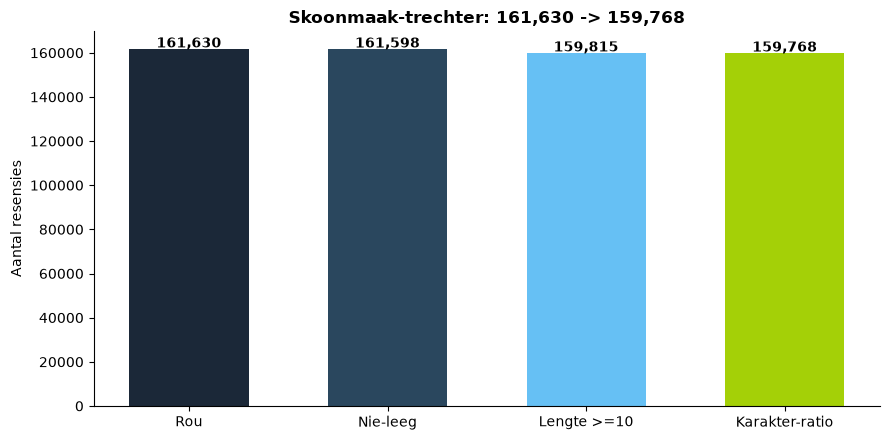

,game_name,review_date,playtime_forever,voted_up,word_count,review_text_clean
0,Elden Ring,2025-08-15 18:44:10,27283.0,True,1,宫崎英高小时候刚出生喊了一声爸爸 结果他母亲的支线断掉了 从此宫崎英高再也没有见过他的妈妈 ...
1,Elden Ring,2025-11-03 08:07:40,20162.0,True,1,宫崎英高小时候刚出生喊了一声爸爸 结果他母亲的支线断掉了 从此宫崎英高再也没有见过他的妈妈 ...
2,Elden Ring,2026-02-14 20:26:44,10192.0,True,1,好想清空记忆 重新推开宁姆格福的大门


In [9]:
t0 = time.time()
df_clean = clean.clean_reviews(df_raw)
dt = time.time() - t0

print(f'Skoonmaak voltooi in {dt:.1f}s')
print(f'Voor: {len(df_raw):,} resensies')
print(f'Na:   {len(df_clean):,} resensies')
print(f'Verwyder: {len(df_raw)-len(df_clean):,} ({(len(df_raw)-len(df_clean))/len(df_raw)*100:.2f}%)')
print(f'Kolomme: {df_clean.shape[1]} (met afgeleide kenmerke)')

# Visualiseer die skoonmaak-trechter (selfstandig bereken)
_em = df_raw['review_text'].isna() | (df_raw['review_text'].str.strip() == '')
_sm = (~_em) & (df_raw['review_text'].str.len() < 10)
_rj = df_raw['review_text'].fillna('').apply(
    lambda s: sum(c.isalpha() or c.isspace() for c in str(s)) / max(len(str(s)), 1) > 0.5)
funnel = [len(df_raw), int((~_em).sum()), int((~_em & ~_sm).sum()), len(df_clean)]
labels = ['Rou', 'Nie-leeg', 'Lengte >=10', 'Karakter-ratio']
fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(labels, funnel, color=['#1b2838', '#2a475e', '#66c0f4', '#a4d007'], width=0.6)
ax.set_ylabel('Aantal resensies')
ax.set_title(f'Skoonmaak-trechter: {funnel[0]:,} -> {funnel[-1]:,}', fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
for b, v in zip(bars, funnel):
    ax.text(b.get_x() + b.get_width()/2, v + 800, f'{v:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

df_clean[['game_name', 'review_date', 'playtime_forever', 'voted_up', 'word_count', 'review_text_clean']].head(3)

### 6.2 Kenmerk-ingenieurswese: genre-one-hot

Die kern van die projek se struktuur: elke resensie kry **one-hot-aanwysers** vir al die genres van sy speletjie (uit `GAME_GENRES`). So kan ons per-genre statistieke bereken sonder om speletjies wat aan meer as een genre behoort dubbel te tel.

In [10]:
genre_cols = [c for c in df_clean.columns if c.startswith('genre_')]
print(f'Genre-one-hot kolomme ({len(genre_cols)}):')
print(', '.join(genre_cols))

print('\nVoorbeeld van die GAME_GENRES-kartering:')
for app_id in [1245620, 730, 252490, 1086940]:
    print(f'  {GAMES[app_id]:25s}: {GAME_GENRES.get(app_id)}')

print('\nResensies per genre (’n speletjie kan in meer as een genre wees):')
for genre, ids in GENRES.items():
    n = df_clean[df_clean['app_id'].isin(ids)].shape[0]
    print(f'  {genre:15s}: {n:>8,}')

Genre-one-hot kolomme (9):
genre_RPG, genre_Shooter, genre_Hero_Shooter, genre_Battle_Royale, genre_Action, genre_Strategy, genre_Adventure, genre_Survival, genre_Free_to_Play

Voorbeeld van die GAME_GENRES-kartering:
  Elden Ring               : ['RPG', 'Action']
  Counter-Strike 2         : ['Shooter', 'Free_to_Play']
  Rust                     : ['Action', 'Survival']
  Baldur's Gate 3          : ['RPG', 'Strategy', 'Adventure']

Resensies per genre (’n speletjie kan in meer as een genre wees):
  RPG            :   39,948
  Shooter        :   53,276
  Hero_Shooter   :   18,357
  Battle_Royale  :   16,622


  Action         :   84,895
  Strategy       :   29,921
  Adventure      :   54,936
  Survival       :   24,975
  Free_to_Play   :   34,967


### 6.3 Stoor die skoon datastel

Ons stoor die resultaat na `data/processed/reviews_clean.csv`. 

**VADER-bewaring:** Die CSV het in vorige lopies VADER-sentimentkolomme gekry. VADER self is **Fase 4**-werk — hier **bewaar** ons net die bestaande kolomme (indien teenwoordig) sodat dit nie weer bereken hoef te word nie. `process_reviews()` in `src/clean.py` doen presies dieselfde.

In [11]:
out_path = f'{PROCESSED_DIR}/reviews_clean.csv'

# Bewaar VADER-kolomme van ’n vorige skoonmaak indien dit bestaan
vader_cols = [c for c in df_clean.columns if c.startswith('vader_')]
if not vader_cols and os.path.exists(out_path):
    prev_cols = pd.read_csv(out_path, nrows=0).columns
    vader_cols = [c for c in prev_cols if c.startswith('vader_')]
    if vader_cols:
        prev = pd.read_csv(out_path, usecols=['review_id'] + vader_cols)
        df_clean = df_clean.merge(prev, on='review_id', how='left')
        print(f'VADER-kolomme bewaar van vorige skoonmaak: {vader_cols}')
        print('  (VADER-sentiment word eers in Fase 4 bereken; ons verloor net nie bestaande werk nie.)')

df_clean.to_csv(out_path, index=False)
print(f'\nSkoon datastel gestoor: {out_path}')
print(f'Rye: {len(df_clean):,}  |  Kolomme: {len(df_clean.columns)}')

VADER-kolomme bewaar van vorige skoonmaak: ['vader_compound', 'vader_positive', 'vader_neutral', 'vader_negative', 'vader_sentiment_label']
  (VADER-sentiment word eers in Fase 4 bereken; ons verloor net nie bestaande werk nie.)



Skoon datastel gestoor: /mnt/c/Users/V/Desktop/Data Analise Project/data/processed/reviews_clean.csv
Rye: 159,768  |  Kolomme: 42


---
## 7. Finale Datastel Struktuur

Die einddatastel word hier volledig beskryf: kolomme, datatipes, ontbrekende waardes, en per-speletjie-oorsig.

In [12]:
print('=== Kolomme en datatipes ===')
print(df_clean.dtypes.to_string())

key_cols = ['review_id', 'review_text', 'timestamp_created', 'playtime_forever', 'language', 'voted_up']
missing = df_clean[key_cols].isna().sum()
print('\n=== Ontbrekende waardes (kernkolomme) ===')
print(missing.to_string() if missing.any() else 'Geen ontbrekende waardes in kernkolomme nie.')
if 'vader_compound' in df_clean.columns:
    print(f'VADER-kolomme ontbrekend: {df_clean["vader_compound"].isna().sum():,} (van {len(df_clean):,})')

print('\n=== Per-speletjie-oorsig ===')
per_game = df_clean.groupby('game_name').agg(
    resensies=('review_id', 'count'),
    positief_pct=('voted_up', 'mean'),
    gem_speeltyd_min=('playtime_forever', 'mean'),
    gem_woorde=('word_count', 'mean')
).sort_values('resensies', ascending=False)
print(per_game.to_string())

print(f'\nDatumbereik: {df_clean["review_date"].min():%Y-%m-%d} tot {df_clean["review_date"].max():%Y-%m-%d}')

=== Kolomme en datatipes ===
app_id                                 int64
game_name                                str
review_id                              int64
author_id                              int64
num_games_owned                        int64
num_reviews                            int64
playtime_forever                     float64
playtime_at_review                   float64
language                                 str
review_text                              str
timestamp_created                      int64
timestamp_updated                      int64
voted_up                                bool
votes_up                               int64
votes_funny                            int64
weighted_vote_score                  float64
steam_purchase                          bool
received_for_free                       bool
written_during_early_access             bool
review_date                    datetime64[s]
review_year                            int32
review_month              

---
## 8. Datakwaliteit-opsomming

’n Laaste kontrole dat die datastel gereed is vir Fase 3.

In [13]:
print('=== Datakwaliteit-opsomming ===')
print(f'Rou resensies:       {len(df_raw):,}')
print(f'Skoon resensies:     {len(df_clean):,}')
print(f'Verwyder:            {len(df_raw)-len(df_clean):,} ({(len(df_raw)-len(df_clean))/len(df_raw)*100:.1f}%)')
print(f'Speletjies:          {df_clean["app_id"].nunique()}/{len(GAMES)}')
print(f'Tale:                {df_clean["language"].nunique()}')
print(f'Datumbereik:         {df_clean["review_date"].min():%Y-%m-%d} tot {df_clean["review_date"].max():%Y-%m-%d}')
print(f'Positiewe resensies: {df_clean["voted_up"].mean()*100:.1f}%')
print(f'Gem. resensielengte: {df_clean["review_length"].mean():.0f} karakters')
print(f'Gem. speeltyd:       {df_clean["playtime_forever"].mean():,.0f} minute')
print(f'Genre-kolomme:       {len([c for c in df_clean.columns if c.startswith("genre_")])} one-hot-aanwysers')
print('\nStatus: GEREED vir Fase 3 — gestruktureer, geen ontbrekende kernwaardes, korrekte datatipes.')

=== Datakwaliteit-opsomming ===
Rou resensies:       161,630
Skoon resensies:     159,768
Verwyder:            1,862 (1.2%)
Speletjies:          33/33
Tale:                30
Datumbereik:         2016-09-17 tot 2026-07-17
Positiewe resensies: 68.0%
Gem. resensielengte: 418 karakters
Gem. speeltyd:       20,726 minute
Genre-kolomme:       9 one-hot-aanwysers

Status: GEREED vir Fase 3 — gestruktureer, geen ontbrekende kernwaardes, korrekte datatipes.


---
## 9. Plan vir Fase 3: Verkennende Data Analise (EDA)

**Hierdie fase word slegs beplan — dit word nie in hierdie notebook uitgevoer nie.**

Met die skoon datastel gereed, beplan ons Fase 3 soos volg:

### 9.1 Basiese statistieke (beskrywend)
- Totale resensies, positief-persentasie, gemiddelde speeltyd en resensielengte — per speletjie **en** per genre.
- Tale-verspreiding, datumbereik, volume per genre (die one-hot-kolomme maak dit moontlik).

### 9.2 Formele statistiese toetse (inferensieel)
- **t-toets:** verskil resensielengte beduidend tussen positiewe en negatiewe resensies?
- **t-toets:** verskil speeltyd tussen positiewe en negatiewe resensies?
- **ANOVA:** verskil resensielengte (of speeltyd) beduidend tussen die 9 genres?
- Korrelasie-analise tussen numeriese kenmerke.

### 9.3 Patrone, tendense en uitdagings
- Volume- en sentimentverspreiding per genre.
- Uitskieters en moontlike data-uitdagings (bv. taalverskille, speletjies met baie min resensies).

### 9.4 Aanvanklike plan vir Fase 4 (diepgaande analise)
- **NLP:** VADER-sentiment (Engels), TF-IDF per genre, genre-netwerke.
- **Regressie:** watter kenmerke voorspel `voted_up` (logisties) en VADER-compound (lineêr), met genre-kenmerke.
- **Visualisering:** interaktiewe Streamlit-dashboard.

Die bevindinge van Fase 3 sal die finale Fase 4-benadering rig.

---
## 10. Bronnelys

1. **Steam API Dokumentasie** — https://steamcommunity.com/dev
2. **Steam Web API (appreviews)** — https://partner.steamgames.com/doc/store/getreviews
3. **Steam Storefront API (appdetails)** — https://wiki.teamfortress.com/wiki/User:RJackson/StorefrontAPI
4. **pandas** — McKinney, W. (2010). Data Structures for Statistical Computing in Python. *Proceedings of the 9th Python in Science Conference*.
5. **requests** — https://requests.readthedocs.io

---
*Gebou vir Fase 2 van die Portefeulje Projek — alle data is openbare Steam-data.*